# Project Overview: Podcast Listening Time Prediction
**Objective:** Predict user listening duration (Listening_Time_minutes) using demographic, behavioral, and platform-specific dynamics.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s5e4')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s5e4


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMRegressor
import pickle
import joblib

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e4/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e4/test.csv')

In [4]:
train_df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [5]:
test_df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [7]:
train_df.shape

(750000, 12)

In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  object 
 7   Publication_Time             250000 non-null  object 
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.0+ MB


In [9]:
test_df.shape

(250000, 11)

In [10]:
train_df.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [11]:
test_df.isnull().sum()

id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

## 3. Exploratory Data Analysis

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [15]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,750000.0,374999.500000,216506.495284,0.0,187499.75000,374999.50000,562499.25000,749999.00
Episode_Length_minutes,662907.0,64.504738,32.969603,0.0,35.73000,63.84000,94.07000,325.24
Host_Popularity_percentage,750000.0,59.859901,22.873098,1.3,39.41000,60.05000,79.53000,119.46
Guest_Popularity_percentage,603970.0,52.236449,28.451241,0.0,28.38000,53.58000,76.60000,119.91
Number_of_Ads,749999.0,1.348855,1.151130,0.0,0.00000,1.00000,2.00000,103.91
Listening_Time_minutes,750000.0,45.437406,27.138306,0.0,23.17835,43.37946,64.81158,119.97


In [16]:
train_df['Genre'].unique()

array(['True Crime', 'Comedy', 'Education', 'Technology', 'Health',
       'News', 'Music', 'Sports', 'Business', 'Lifestyle'], dtype=object)

In [17]:
train_df['Publication_Day'].unique()

array(['Thursday', 'Saturday', 'Tuesday', 'Monday', 'Sunday', 'Wednesday',
       'Friday'], dtype=object)

In [18]:
train_df['Publication_Time'].unique()

array(['Night', 'Afternoon', 'Evening', 'Morning'], dtype=object)

In [19]:
train_df['Guest_Popularity_percentage'].unique()

array([    nan,  75.95 ,   8.97 , ...,  99.597, 107.58 , 105.44 ])

In [20]:
train_df['Number_of_Ads'].unique()

array([  0.  ,   2.  ,   3.  ,   1.  ,  53.37,    nan, 103.91, 103.  ,
        53.42, 103.75,  12.  , 103.25, 103.88])

In [21]:
train_df['Episode_Sentiment'].unique()

array(['Positive', 'Negative', 'Neutral'], dtype=object)

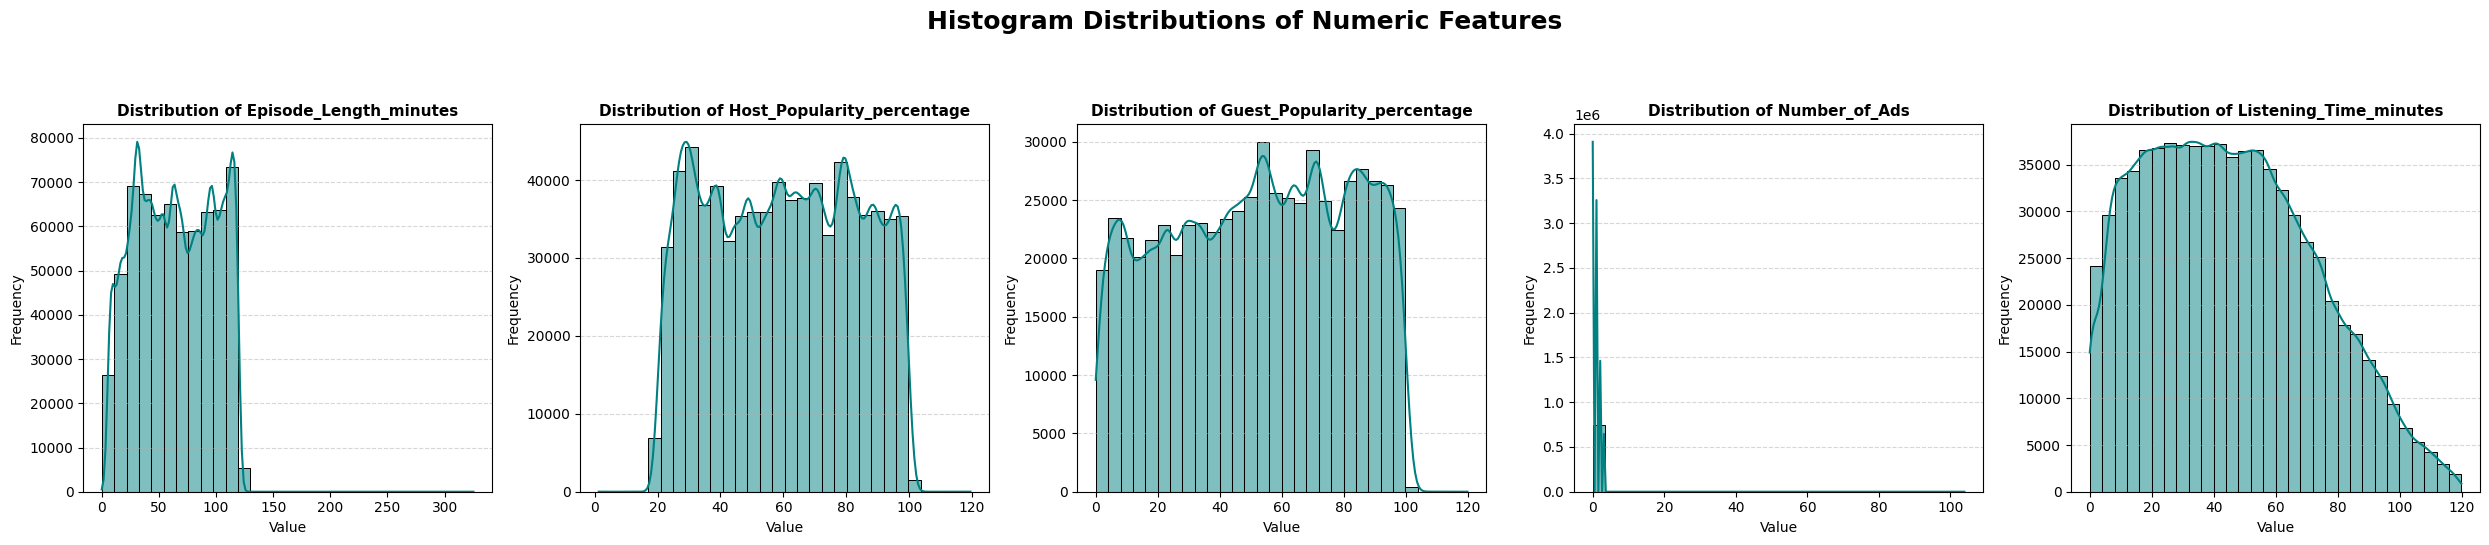

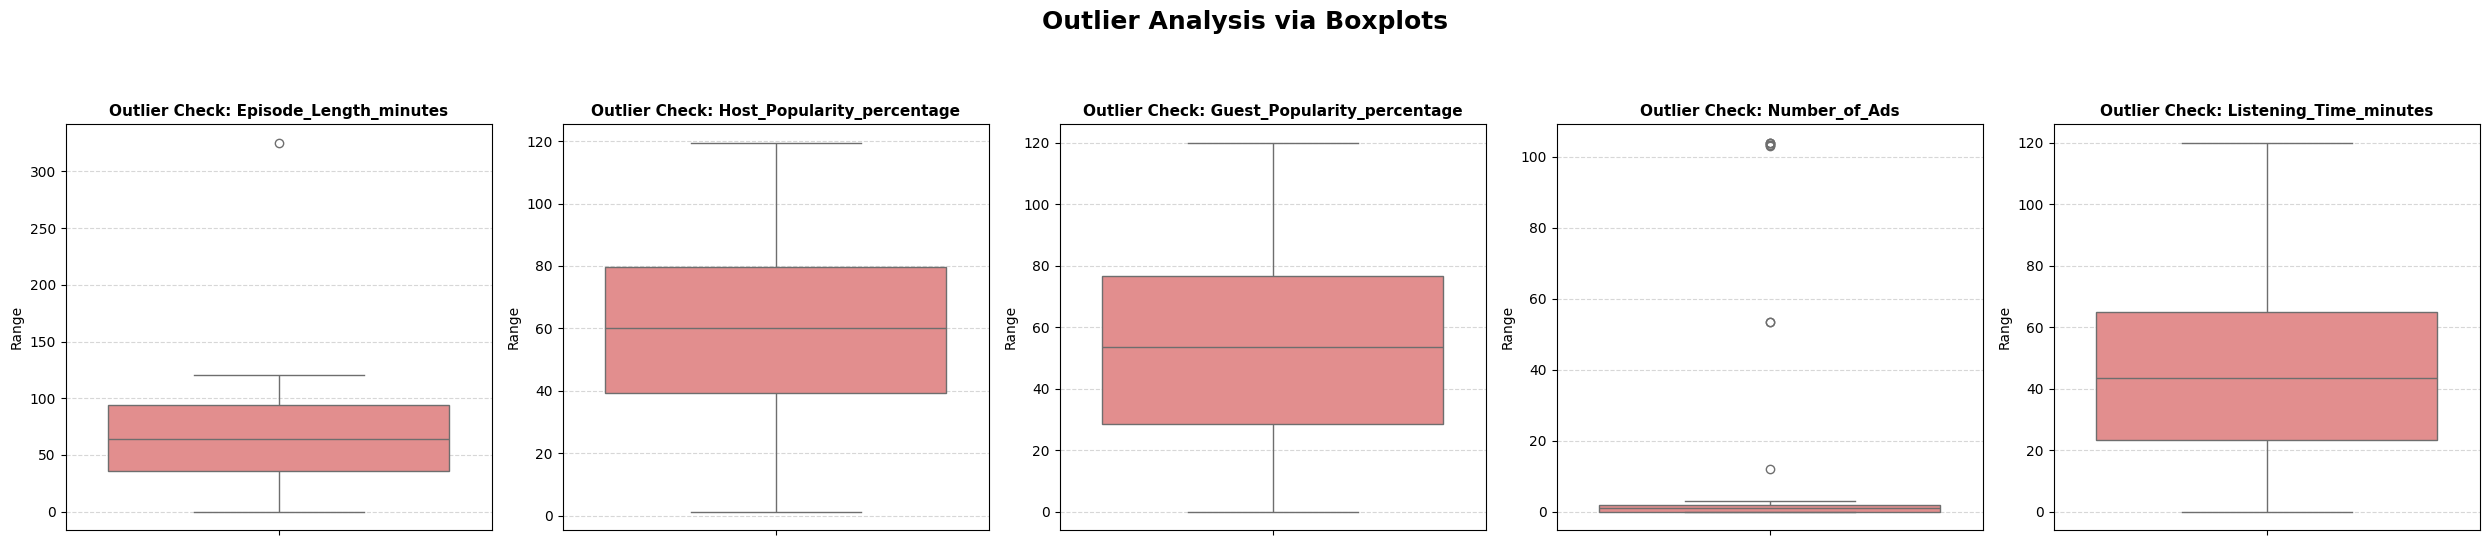

In [22]:
num_features = [
    'Episode_Length_minutes', 'Host_Popularity_percentage', 
    'Guest_Popularity_percentage', 'Number_of_Ads', 'Listening_Time_minutes'
]

# Histogram
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

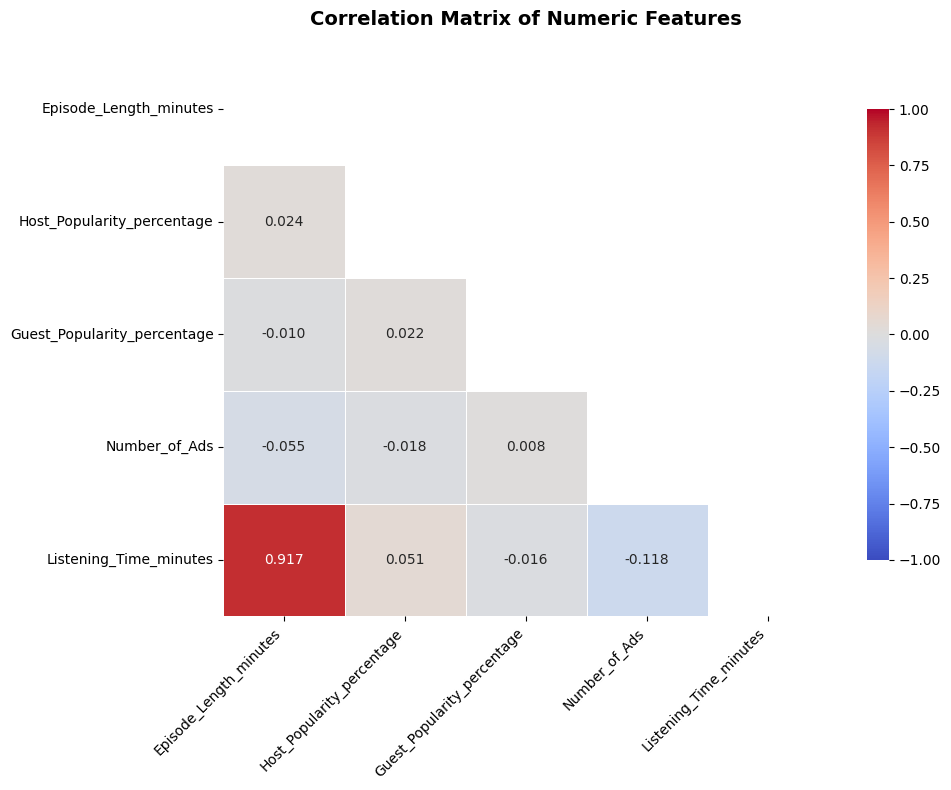

In [23]:
num_features = [
    'Episode_Length_minutes', 'Host_Popularity_percentage', 
    'Guest_Popularity_percentage', 'Number_of_Ads', 'Listening_Time_minutes'
]

corr_matrix = train_df[num_features].corr()

plt.figure(figsize=(10, 8))

import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,          
    fmt=".3f",           
    cmap='coolwarm',     
    vmin=-1, vmax=1,   
    linewidths=0.5,      
    cbar_kws={"shrink": 0.8} 
)

plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_57/3425591818.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_57/3425591818.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_57/3425591818.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_57/3425591818.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
/tmp/ipykernel_57/3425591818.py:8: FutureWarning: 

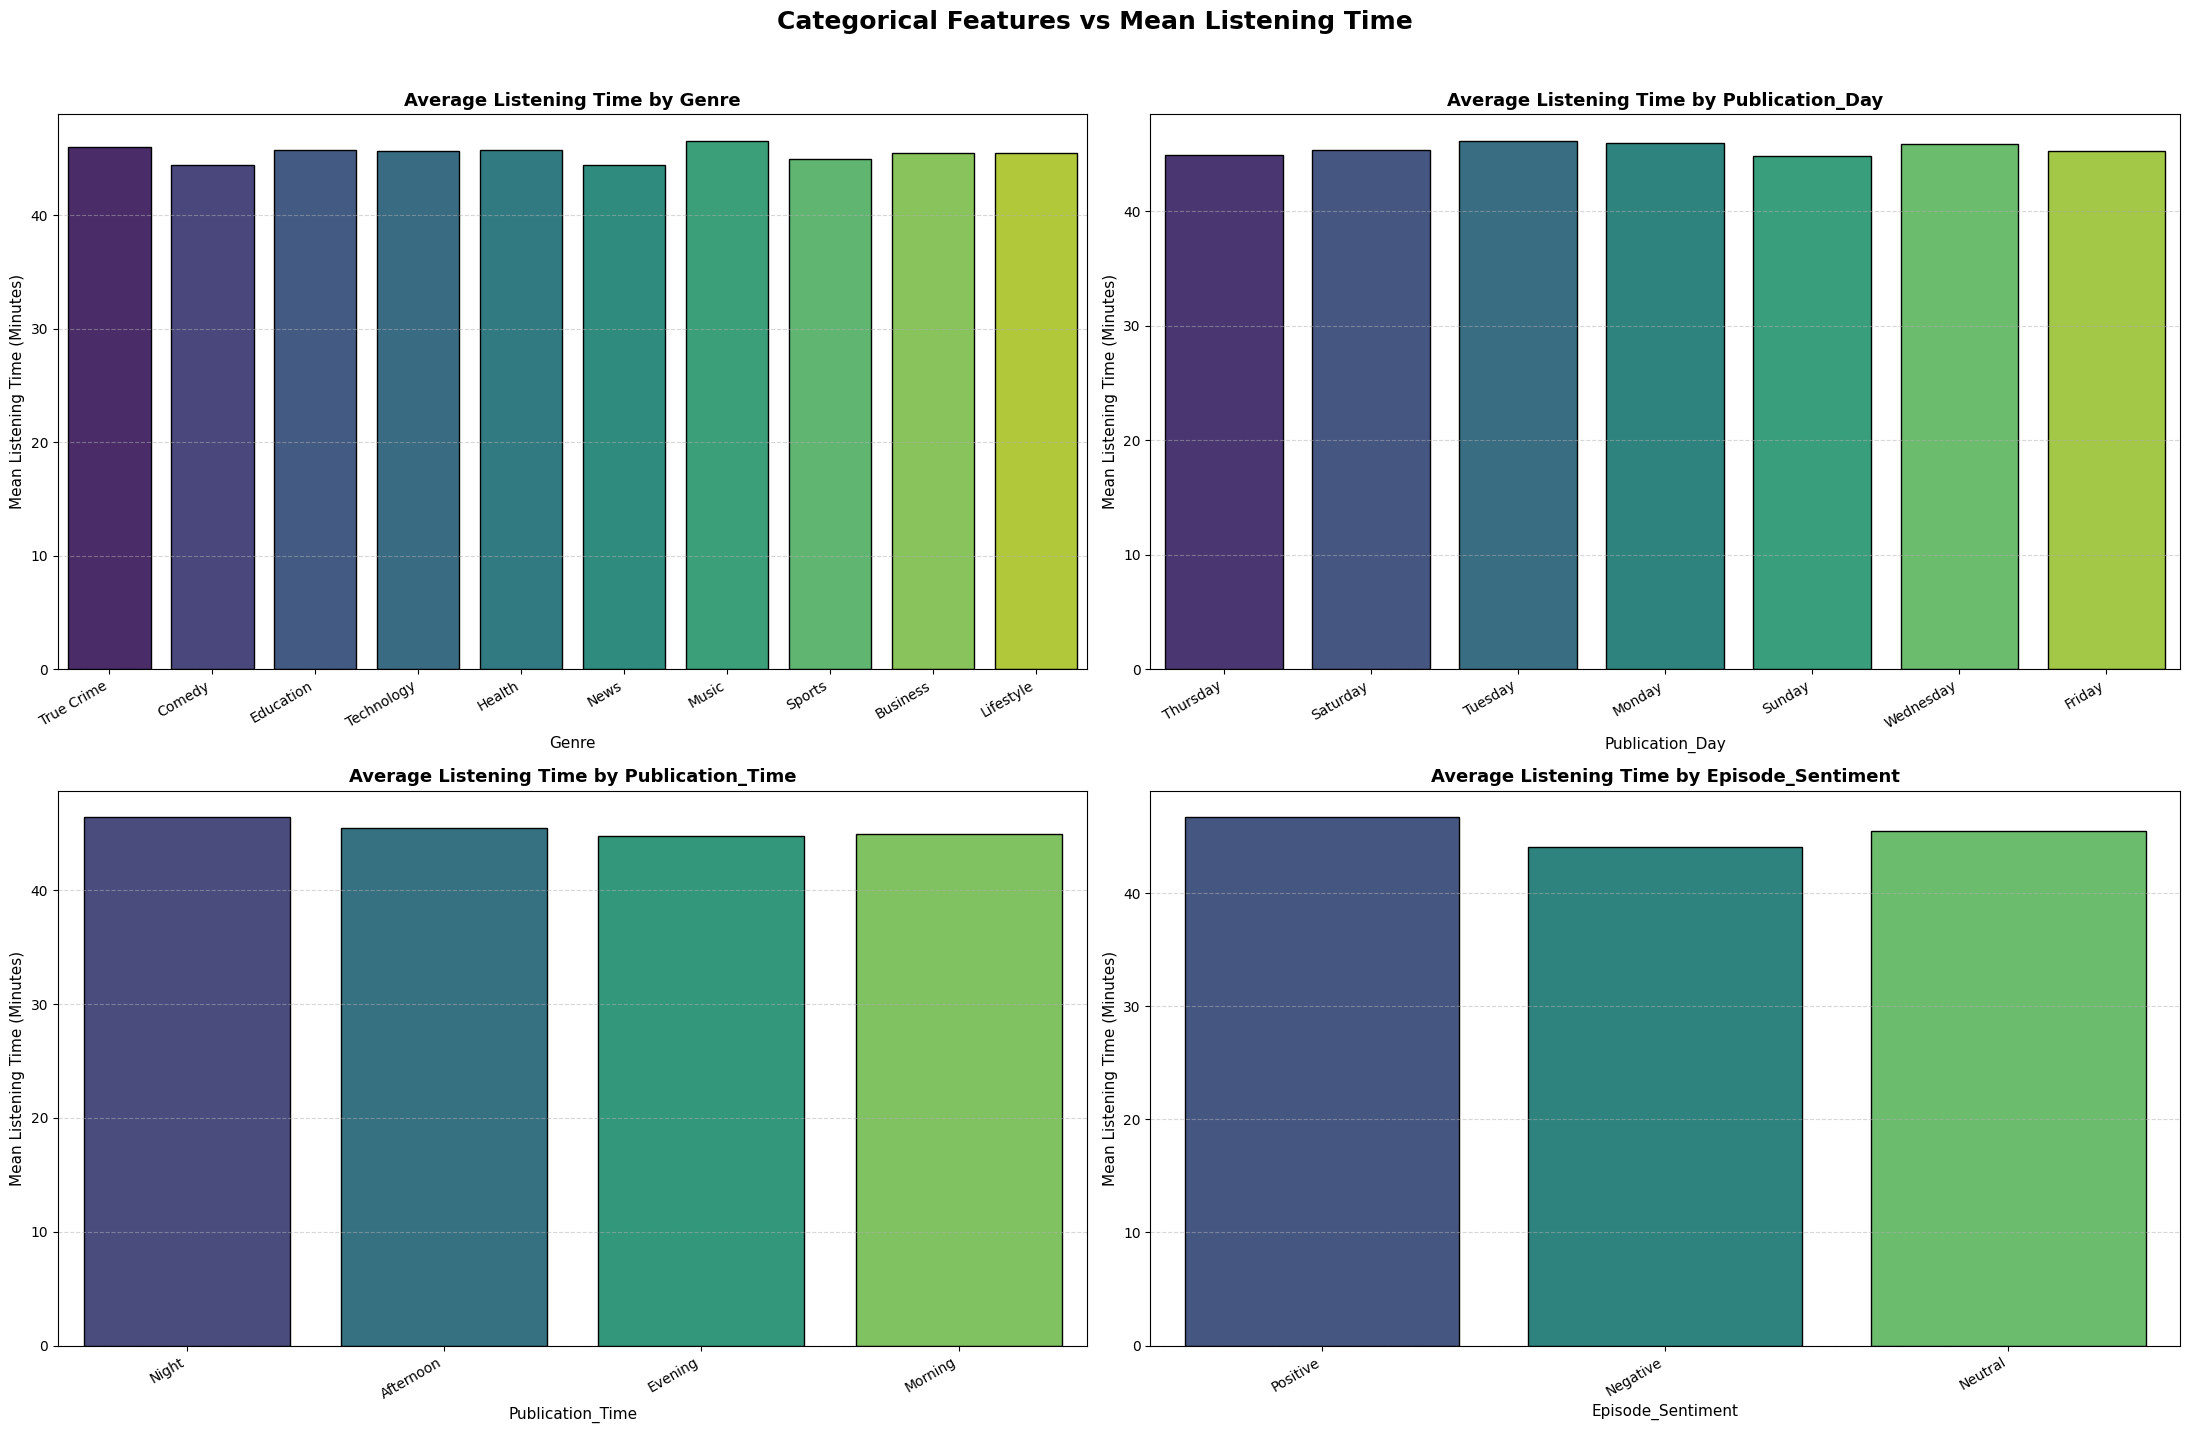

In [24]:
cat_features = ['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):

    sns.barplot(
        data=train_df, 
        x=col, 
        y='Listening_Time_minutes', 
        ax=axes[i], 
        palette='viridis',
        edgecolor='black',
        errorbar=None
    )
    
    axes[i].set_title(f'Average Listening Time by {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Mean Listening Time (Minutes)', fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Categorical Features vs Mean Listening Time', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering (FE) & Data Preprocessing

In [25]:
train_df['is_train'] = 1
test_df['is_train'] = 0

In [26]:
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [27]:
# Missing values imply no guest was present; creating a binary flag and filling with 0
combined_df['Is_Guest_Present'] = combined_df['Guest_Popularity_percentage'].notnull().astype(int)
combined_df['Guest_Popularity_percentage'] = combined_df['Guest_Popularity_percentage'].fillna(0)

In [28]:
# Handling the single missing value in the training split using the train median
train_ads_median = combined_df[combined_df['is_train'] == 1]['Number_of_Ads'].median()
combined_df['Number_of_Ads'] = combined_df['Number_of_Ads'].fillna(train_ads_median)

In [29]:
# Using the 0.917 linear correlation: Predict missing lengths using Listening_Time_minutes
train_data = combined_df.query("is_train == 1").dropna(subset=['Listening_Time_minutes', 'Episode_Length_minutes'])

lr_model = LinearRegression()
lr_model.fit(train_data[['Listening_Time_minutes']], train_data['Episode_Length_minutes'])

# Imputing missing Episode_Length_minutes values in the train set
valid_listening_time = combined_df['Listening_Time_minutes'].notna()
predicted_lengths = lr_model.predict(combined_df.loc[valid_listening_time, ['Listening_Time_minutes']])

# Tahminleri hesapla ve doğrudan ilgili satırların boşluklarına ata
predictions = lr_model.predict(combined_df.loc[valid_listening_time, ['Listening_Time_minutes']])
combined_df.loc[valid_listening_time, 'Episode_Length_minutes'] = combined_df.loc[valid_listening_time, 'Episode_Length_minutes'].fillna(pd.Series(predictions))

In [30]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id                           1000000 non-null  int64  
 1   Podcast_Name                 1000000 non-null  object 
 2   Episode_Title                1000000 non-null  object 
 3   Episode_Length_minutes       971264 non-null   float64
 4   Genre                        1000000 non-null  object 
 5   Host_Popularity_percentage   1000000 non-null  float64
 6   Publication_Day              1000000 non-null  object 
 7   Publication_Time             1000000 non-null  object 
 8   Guest_Popularity_percentage  1000000 non-null  float64
 9   Number_of_Ads                1000000 non-null  float64
 10  Episode_Sentiment            1000000 non-null  object 
 11  Listening_Time_minutes       750000 non-null   float64
 12  is_train                     1000000 non-nu

In [31]:
categorical_features = ['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']

combined_df = pd.get_dummies(combined_df, columns=categorical_features, drop_first=True, dtype=int)

In [32]:
combined_df.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Host_Popularity_percentage', 'Guest_Popularity_percentage',
       'Number_of_Ads', 'Listening_Time_minutes', 'is_train',
       'Is_Guest_Present', 'Genre_Comedy', 'Genre_Education', 'Genre_Health',
       'Genre_Lifestyle', 'Genre_Music', 'Genre_News', 'Genre_Sports',
       'Genre_Technology', 'Genre_True Crime', 'Publication_Day_Monday',
       'Publication_Day_Saturday', 'Publication_Day_Sunday',
       'Publication_Day_Thursday', 'Publication_Day_Tuesday',
       'Publication_Day_Wednesday', 'Publication_Time_Evening',
       'Publication_Time_Morning', 'Publication_Time_Night',
       'Episode_Sentiment_Neutral', 'Episode_Sentiment_Positive'],
      dtype='object')

## 5. Model Training, Optimization & Deployment Strategy

In [33]:
cols = ['Podcast_Name', 'Episode_Title', 'Listening_Time_minutes', 'is_train', 'id']
x = combined_df.query("is_train == 1").drop(columns=cols, errors='ignore')
y = combined_df.query("is_train == 1")['Listening_Time_minutes']

In [34]:
x.shape

(750000, 25)

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

def algo_test(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor(n_estimators=100, random_state=42) 
    ada = AdaBoostRegressor(n_estimators=50, random_state=42)
    dt = DecisionTreeRegressor(max_depth=10, random_state=42)
    xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, n_jobs=-1, random_state=42)
    lgb = LGBMRegressor(n_estimators=1500, learning_rate=0.03, num_leaves=64, n_jobs=-1, random_state=42)
    cat = CatBoostRegressor(iterations=1000, learning_rate=0.05, thread_count=-1, verbose=0, random_state=42)
    
    algos = [L, R, Lass, E, sgd, ETR, GBR, ada, dt, xgb, lgb, cat]
    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Extra Tree', 'Gradient Boosting', 'AdaBoost', 
        'Decision Tree', 'XGBRegressor', 'LGBMRegressor', 'CatBoostRegressor'
    ]
    
    r_squared = []
    rmse = []
    mae = []
    
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)
    
    for algo, name in zip(algos, algo_names):
        print(f" Now training and evaluating: {name}...")
        
        model_fit = algo.fit(x_train_scaled, y_train)
        predictions = model_fit.predict(x_test_scaled)
        
        r_squared.append(r2_score(y_test, predictions))
        rmse.append(mean_squared_error(y_test, predictions) ** 0.5)
        mae.append(mean_absolute_error(y_test, predictions))
        
        print(f" {name} processing finished successfully.\n")
    
    rtable = result.assign(R_Squared=r_squared, RMSE=rmse, MAE=mae).sort_values('R_Squared', ascending=False)
    return rtable

In [36]:
model = algo_test(x, y)

 Now training and evaluating: Linear...
 Linear processing finished successfully.

 Now training and evaluating: Ridge...
 Ridge processing finished successfully.

 Now training and evaluating: Lasso...
 Lasso processing finished successfully.

 Now training and evaluating: ElasticNet...
 ElasticNet processing finished successfully.

 Now training and evaluating: SGD...
 SGD processing finished successfully.

 Now training and evaluating: Extra Tree...
 Extra Tree processing finished successfully.

 Now training and evaluating: Gradient Boosting...
 Gradient Boosting processing finished successfully.

 Now training and evaluating: AdaBoost...
 AdaBoost processing finished successfully.

 Now training and evaluating: Decision Tree...
 Decision Tree processing finished successfully.

 Now training and evaluating: XGBRegressor...
 XGBRegressor processing finished successfully.

 Now training and evaluating: LGBMRegressor...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the ove

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


 LGBMRegressor processing finished successfully.

 Now training and evaluating: CatBoostRegressor...
 CatBoostRegressor processing finished successfully.



In [37]:
model

,R_Squared,RMSE,MAE
LGBMRegressor,0.869732,9.790526,7.394434
XGBRegressor,0.868843,9.823890,7.412424
CatBoostRegressor,0.867831,9.861708,7.449205
Gradient Boosting,0.866594,9.907749,7.481013
Decision Tree,0.865967,9.931029,7.469943
Ridge,0.860186,10.142928,7.666601
Linear,0.860169,10.143559,7.667459
SGD,0.859690,10.160899,7.666375
Lasso,0.828616,11.229817,8.757285
AdaBoost,0.820528,11.491740,9.198369


In [38]:
x_train_final = combined_df[combined_df['is_train'] == 1].drop(columns=['is_train', 'Listening_Time_minutes', 'id', 'Podcast_Name', 'Episode_Title'])
y_train_final = combined_df[combined_df['is_train'] == 1]['Listening_Time_minutes']
x_test_final = combined_df[combined_df['is_train'] == 0].drop(columns=['is_train', 'Listening_Time_minutes', 'id', 'Podcast_Name', 'Episode_Title'])
test_ids = combined_df[combined_df['is_train'] == 0]['id']

In [39]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train_final)
x_test_scaled = scaler.transform(x_test_final)

In [40]:
XGBR = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [41]:
XGBR.fit(x_train_scaled, y_train_final)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [42]:
predictions_XGBR = XGBR.predict(x_test_scaled)

In [43]:
submission = pd.DataFrame({
    'id': combined_df.query("is_train == 0")['id'],
    'Listening_Time_minutes': predictions_XGBR
})

submission.to_csv('submission_XGBR.csv', index=False)

In [44]:
LGBMR = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [45]:
LGBMR.fit(x_train_final, y_train_final)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 812
[LightGBM] [Info] Number of data points in the train set: 750000, number of used features: 25
[LightGBM] [Info] Start training from score 45.437406


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1500,
              num_leaves=64, random_state=42, subsample=0.8)

In [46]:
predictions_LGBMR = LGBMR.predict(x_test_final)

In [47]:
submission = pd.DataFrame({
    'id': combined_df.query("is_train == 0")['id'],
    'Listening_Time_minutes': predictions_LGBMR
})

submission.to_csv('submission_LGBMR.csv', index=False)

In [50]:
model_filename_pickle = 'podcast_lgb_model.pkl'
with open(model_filename_pickle, 'wb') as file:
    pickle.dump(LGBMR, file)

# Option 2: Saving using joblib (Highly recommended for large tree-based models)
model_filename_joblib = 'podcast_lgb_model.joblib'
joblib.dump(LGBMR, model_filename_joblib)

['podcast_lgb_model.joblib']